In [1]:
from cnn_connectome.datasets.make_movie_from_pano import GetNaturalMovies
from cnn_connectome.utils.plotting import use_static_flyvis_colorbar, show_hdr, sample_animation
from flyvis.analysis import animations
import numpy as np
from pathlib import Path
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Video, display
from math import ceil
sns.set_context("poster")
plt.rcParams["figure.dpi"] = 100

/home/guardomayas/miniforge3/envs/cnn_connectome/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = Path("/home/guardomayas/NUIN/pano_scenes/")
PPD = 360/(927) #Imgs width #Pano scenes (251, 927)
ommSizePix = int(np.ceil(5/PPD))  #Equivalent to kernel size in Conv2d
print("Pixel size (deg):", f"{PPD:.3f}")
print("Omm size (pixels):", ommSizePix, '\n')

print("Full eye image requirements:")
print(30*ommSizePix+1, "x", 30*ommSizePix+1, "Px" )


Pixel size (deg): 0.388
Omm size (pixels): 13 

Full eye image requirements:
391 x 391 Px


In [3]:
dataset = GetNaturalMovies(data_path=data_path)


[Vel] vel_traces: (5, 2, 181)
[Vel] positions:  (5, 2, 181)
[Phase] Phase indices: (5, 3, 927)
[Movies] Total movies: 30
[Render] all_movies: (30, 181, 251, 250)


In [12]:
sequences = dataset.all_movies
vel_traces = dataset.vel_traces

print(sequences.shape)

(30, 181, 251, 250)


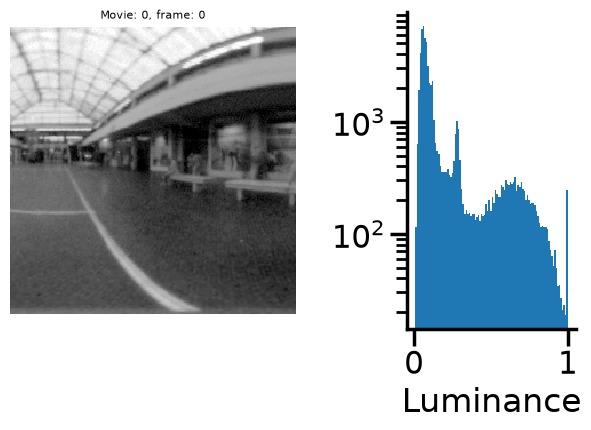

In [23]:
movie_idx = 0
frame_idx = 0
frame  = sequences[movie_idx,frame_idx,:,:]
fig, axes = plt.subplots(1,2, width_ratios=(1.7,1))

show_hdr(frame, ax=axes[0],
        title=f"Movie: {movie_idx}, frame: {frame_idx}")

axes[1].hist(frame.ravel(), bins=100)
axes[1].set_yscale('log')
axes[1].set_box_aspect()  # smaller value makes it shorter
axes[1].set_xlabel("Luminance")

fig.tight_layout()


In [ ]:

movies_dir = Path("_movies")
movies_dir.mkdir(exist_ok=True)
save_path = movies_dir / "sample_0.mp4"
print("#"*60)
print("Visualization is in Log-scale. Haven't computed contrast yet")
anim = sample_animation(dataset, 0, viz_fps=20, save_path=save_path)
display(Video(save_path, embed=True))

############################################################
Visualization is in Log-scale. Haven't computed contrast yet
Saving animation to _movies/sample_0.mp4...


In [14]:
@root(renderings_dir)
class Hex_RenderedNaturalMov(Directory):

    class Config(dict):
        extent: int
        kernel_size: int
        subset_idx: list
        data_path: str = 'pano_scenes/'
        batch_idx: int = 0
        batch_size: int = 5
        traces_per_img: int = 2
        phases_per_img: int = 3
        halfLife: float = 0.2
        velStd: float = 100
        sampleFreq: int = 60
        totalTime: int = 3
        precentile_scale: float = 99.0
        fov: int = 250

    def __init__(self, config: Config):
        """
        Render natural movies with BoxEye and store them one sequence per group
        on disk under this Directory. Subsequent constructions with the same
        config will *reuse* the stored data instead of re-rendering.
        """

        # If this directory already has rendered sequences, do nothing
        if len(self) > 0:
            return

        # 1. Build natural movies (cartesian)
        gen = GetNaturalMovies(
            data_path=config.data_path,
            batch_idx=config.batch_idx,
            batch_size=config.batch_size,
            traces_per_img=config.traces_per_img,
            phases_per_img=config.phases_per_img,
            halfLife=config.halfLife,
            velStd=config.velStd,
            sampleFreq=config.sampleFreq,
            totalTime=config.totalTime,
            percentile_scale = config.percentile_scale,
            fov=config.fov,
        )

        # gen.movies: (N, 3) of (img_idx, trace_idx, phase_idx)
        sequences = gen.all_movies
        vel_traces = gen.vel_traces

        # 2. BoxEye rendering (hex) and store per sequence
        receptors = BoxEye(
            extent=config.extent,
            kernel_size=config.kernel_size,
        )

        n_seq = sequences.shape[0]
        subset_idx = getattr(config, "subset_idx", []) or list(range(n_seq))

        with tqdm(total=len(subset_idx), desc="Rendering natural movies") as pbar:
            for global_idx, index in enumerate(subset_idx):
                cartesian_seq = sequences[[index]]
                lum_hex = receptors(cartesian_seq).cpu().numpy()[0]  # (T, 1, n_hex)

                img_idx, trace_idx, phase_idx = gen.movies[index]
                v = vel_traces[img_idx, trace_idx]  # (T,)

                seq_name = (
                    f"sequence_{index:05d}"
                    f"_img_{img_idx:03d}"
                    f"_trace_{trace_idx:02d}"
                    f"_phase_{phase_idx:02d}"
                )

                self[f"{seq_name}/lum"] = lum_hex   # (T, 1, n_hex)
                self[f"{seq_name}/vel"] = v         # (T,)

                pbar.update()

    def __call__(self, seq_id: int):
        """Return lum + vel for the seq_id-th rendered sequence (sorted order)."""
        group = sorted(self)[seq_id]
        data = self[group]
        return {key: data[key][:] for key in sorted(data)}  # 'lum', 'vel'

NameError: name 'root' is not defined